1. What is the non-trivial equilibrium population size?

To find the two system equilibriums one can set the population rate equation to zero (where the popluation growth stays the same).
This reveals the first, trivial, solution where rn = 0 and therefore n = 0. At a population of 0 the rate of change will also be zero. 
The non-trivial solution (where (1 - (n/K)^Ø) = 0) reveals at which non-zero population size is the population size unchanging.

To solve for the non-trivial (1 - (n/K)^Ø) = 0, one must subtract 1, rid the negative, take the root of one by the constant theta, and multiply by the constant K.
The final non-trivial solution for the equlibrium of population size is: 
n* = K(Ø√1). Since Ø and K are positive constants and population size cannot be negative, Ø√1 will equal 1 and finally:
n* = K.


2. Show that it is a stable equilibrium.

Given that this growth equation is one-dimensional, in order to find whether the non-trivial equilibrium is stable, one can determine whether our solution f'(n*) < 0. Stability shows whether populations close to the equilibrium will approach it (from either end). To determine this, we can take the derivitive of the function and plug in our equilibrium. Please see the work below for the deterimination of the derivitive of our intitial population function (f(n) = dn/dt) using the product rule to be:
f'(n) = r(1 - (n/k)^Ø) + rn(-(Ø/k^Ø)(n^Ø-1))

When plugging in our non-trivial equilibrium of K for n, the left hand side cancels out to zero as r * 0 is zero. When solving the right hand side of the equation:
f'(n*) = - (r * Ø). Because r and Ø are always positive constants f'(n*) will always be negative. Therefore the non-trivial equilibrium is stable. 


3. Write a script in R that plots, in a single diagram, the function f(n) = rn(1 - (n/k)^theta) vs. n, for a suite of theta values, ranging from 0.2 - 3.

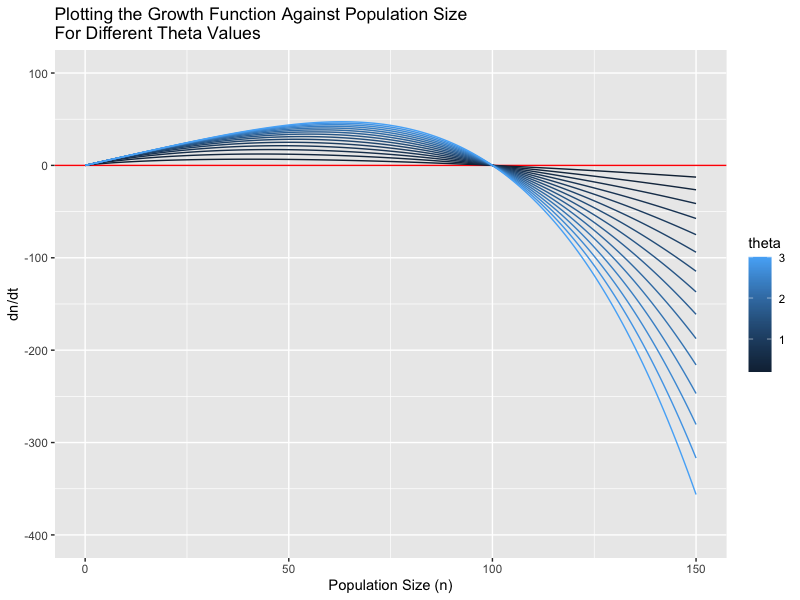

In [ ]:
install.packages("ggplot2") # installing ggplot2
library(ggplot2) # loading in ggplot2

theta <- seq(0.2, 3, by = 0.2) # seq of numbers by 0.2 from 0.2 - 3
r <- 1 # setting an arbitrary initial growth rate of 1
K <- 100 # setting an arbitrary carrying capacity of 100
n <- seq(0, 150) # setting up arbitrary population sizes of 0-150

growth <- function(n, theta) {   # growth rate function as defined in the exam to call on for calculating growth rate
  ((r*n)*(1-((n/K)^theta)))
}

plot <- ggplot(data.frame(n = n), aes(x = n)) +   # opening plot with population sizes between 0-150 on the x-axis
  geom_hline(yintercept = 0, color = "red") + # adding a blue line which shows where the growth rate is 0 (equillibriums)
  scale_y_continuous(limits = c(100,-400), # y - axis limits
                    breaks = seq(-400,100, by = 100)) + # adjusting y axis spacing and tick marks
  labs(
    title = "Plotting the Growth Function Against Population Size\nFor Different Theta Values",
    y = ("dn/dt"),
    x = ("Population Size (n)")
  ) 

for (i in seq_along(theta)) {   # initiate a for loop that loops through the index of 10 random theta values
  th <- theta[i] # save the theta value at index i 
  df <- data.frame(n = n, growth = growth(n, th), theta = th) # create a data frame that stores the population size and growth rate at the current theta value
  plot <- plot + geom_line(data = df, aes(x = n, y = growth, color = theta)) # add this line (pop size vs. growth rate) to the existing plot

}

plot # generate the plot



4. Write another script that plots, in a single diagram, the per capita growth rate f(n)/n vs. n for a suite of theta values, ranging from 0.2 - 3.

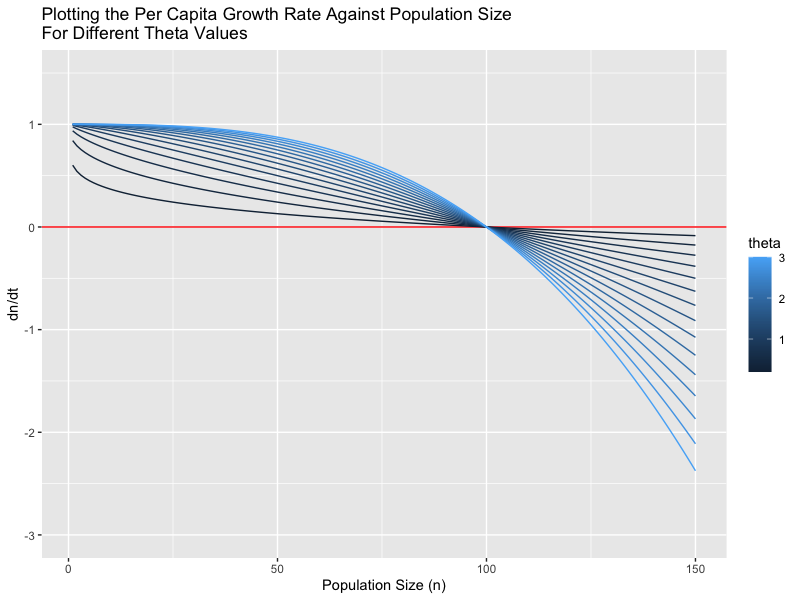

In [ ]:
install.packages("ggplot2") # installing ggplot2
library(ggplot2) # loading in ggplot2

theta <- seq(0.2, 3, by = 0.2) # seq of numbers by 0.2 from 0.2 - 3
r <- 1 # setting an arbitrary initial growth rate of 1
K <- 100 # setting an arbitrary carrying capacity of 100
n <- seq(1, 150) # setting up arbitrary population sizes of 1-150 (starting at 1 to avoid error when dividing by n ( cannot divide by 0))

per_cap_growth <- function(n, theta) {   # growth rate function as defined in the exam to call on for calculating growth rate
  (((r*n)*(1-((n/K)^theta))))/(n)
}

plot <- ggplot(data.frame(n = n), aes(x = n)) +   # opening plot with population sizes between 0-150 on the x-axis
  geom_hline(yintercept = 0, color = "red") + # adding a blue line which shows where the growth rate is 0 (equillibriums)
  scale_y_continuous(limits = c(1.5,-3), # y - axis -300 to 100 limits
                    breaks = seq(-3,1.5, by = 1)) + # adjusting y axis spacing and tick marks
  labs(
    title = "Plotting the Per Capita Growth Rate Against Population Size\nFor Different Theta Values",
    y = ("dn/dt"),
    x = ("Population Size (n)")
  ) 

for (i in seq_along(theta)) {   # initiate a for loop that loops through the index of 10 random theta values
  th <- theta[i] # save the theta value at index i 
  df <- data.frame(n = n, growth = per_cap_growth(n, th), theta = th) # create a data frame that stores the population size and growth rate at the current theta value (also add the current theta as a column for coloring)
  plot <- plot + geom_line(data = df, aes(x = n, y = growth, color = theta)) # add this line (pop size vs. growth rate) to the existing plot, color by theta column

}

plot # generate the plot



5. The plot in (4) is a good illustration of the density dependence (how population density (size) affects population growth). Can you describe, in biological terms, the effect of theta on this density dependence? Put in another way, what ecological circumstance could render a low or high theta? An imaginary example or two could be useful.

As population size grows, growth rate slows. This is illustrated in the overall plot of per capita growth rate. This is intuitive as larger population sizes reach bottlenecks such as resource availability, competition, or space. When looking specifically at theta, higher theta values lead to a more dramatic decrease in growth rate as the population reaches equilibrium compared to lower theta values (as theta exponentiates part of the growth equation). This represents how severely a specific population is impacted by bottlenecks. As an example, a species of fish exists that relys exclusively on plankton for survival. If two populations exist, one where no other animals compete for plankton, and another where a different species of fish also relies on plankton for survival, the species that endures competition over resources will have a higher theta. This is because it is more strongly density-dependent: the bigger the population the bigger the bottleneck due to competition and a sharper decrease in growth rate is necessary to reach equilibrium. The species without competition will have a lower theta as the population is less density-dependent and its growth rate will likely behave more linearly as it approaches equilibrium. 